# 03a — Paired classification

This notebook addresses the paired-data part of the report.

Main question:

> If each participant has both an Eyes Open (EO) and Eyes Closed (EC) recording, can we identify which recording is EC by comparing the two recordings within the same participant?

This is the setting used by the simple posterior-alpha baseline.

The notebook compares:

1. Simple paired alpha rules:
   - Oz alpha
   - Occipital alpha
   - Posterior alpha

2. Paired logistic-regression models:
   - one-feature posterior alpha
   - individual posterior-channel alpha features
   - posterior multiband Welch features
   - FOOOF/specparam features
   - combined features

The key idea is that the complex models are evaluated using the same **within-participant paired contrast** as the simple baseline.


In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

warnings.filterwarnings("ignore")

# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

DATA_DIR = PROJECT_ROOT / "data_processed"
RESULTS_DIR = DATA_DIR / "model_results"
FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RECORDING_FEATURES_FILE = DATA_DIR / "recording_features.csv"
FOOOF_FEATURES_FILE = DATA_DIR / "fooof_features.csv"

PAIRED_RESULTS_FILE = RESULTS_DIR / "paired_results.csv"
PAIRED_PREDICTIONS_FILE = RESULTS_DIR / "paired_predictions.csv"
PAIRED_COEFFICIENTS_FILE = RESULTS_DIR / "paired_coefficients.csv"

recording_features = pd.read_csv(RECORDING_FEATURES_FILE)

print("Recording features:", recording_features.shape)
recording_features.head()


Recording features: (1216, 62)


,recording_id,participant_id,pair_id,condition,age,sex,handedness,sfreq,duration_sec,n_eeg_channels,...,ch_PO10_alpha_log,ch_P5_alpha_log,ch_P1_alpha_log,ch_P2_alpha_log,ch_P6_alpha_log,ch_PO7_alpha_log,ch_PO3_alpha_log,ch_POz_alpha_log,ch_PO4_alpha_log,ch_PO8_alpha_log
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,1000.0,183.999,64,...,-9.898763,-10.300306,-10.528587,-10.350076,-10.161307,-9.795682,-10.151584,-10.239191,-10.092667,-9.849979
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,EO,60,F,right,1000.0,183.999,64,...,-10.851142,-11.027301,-11.165257,-11.014861,-10.902652,-10.851297,-10.991615,-10.978965,-10.889543,-10.829276
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,EC,67,M,right,1000.0,183.999,64,...,-10.026011,-10.362393,-10.406497,-10.204621,-10.189385,-10.106385,-10.045444,-9.966155,-9.900258,-9.775134
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,EO,67,M,right,1000.0,183.999,64,...,-10.851334,-11.114673,-11.230478,-11.024508,-11.001005,-11.002198,-11.086947,-11.108040,-10.959196,-10.777771
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,EC,44,F,right,1000.0,217.999,64,...,-10.677774,-11.060391,-11.191334,-11.155817,-10.936547,-10.770354,-10.887820,-10.819083,-10.783156,-10.628434


## 1. Load and merge FOOOF features

FOOOF/specparam features are optional complex features. If the file exists, they are merged by `recording_id`.


In [2]:
if FOOOF_FEATURES_FILE.exists():
    fooof_features = pd.read_csv(FOOOF_FEATURES_FILE)

    fooof_cols = [
        "recording_id",
        "fooof_include",
        "fooof_has_alpha_peak",
        "fooof_alpha_cf",
        "fooof_alpha_peak_power",
        "fooof_alpha_bandwidth",
        "fooof_aperiodic_exponent",
        "fooof_r_squared",
        "fooof_error",
    ]

    fooof_cols = [col for col in fooof_cols if col in fooof_features.columns]

    features = recording_features.merge(
        fooof_features[fooof_cols],
        on="recording_id",
        how="left",
        validate="one_to_one",
    )

    print("FOOOF features:", fooof_features.shape)
    print("Merged features:", features.shape)

else:
    features = recording_features.copy()
    print("FOOOF feature file not found. Continuing without FOOOF features.")

features.head()


FOOOF features: (1216, 21)
Merged features: (1216, 70)


,recording_id,participant_id,pair_id,condition,age,sex,handedness,sfreq,duration_sec,n_eeg_channels,...,ch_PO4_alpha_log,ch_PO8_alpha_log,fooof_include,fooof_has_alpha_peak,fooof_alpha_cf,fooof_alpha_peak_power,fooof_alpha_bandwidth,fooof_aperiodic_exponent,fooof_r_squared,fooof_error
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,1000.0,183.999,64,...,-10.092667,-9.849979,True,True,9.960222,1.782206,1.000000,1.274694,0.985733,0.068630
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,EO,60,F,right,1000.0,183.999,64,...,-10.889543,-10.829276,True,True,10.917563,0.619877,2.877636,1.482230,0.992011,0.037988
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,EC,67,M,right,1000.0,183.999,64,...,-9.900258,-9.775134,True,True,8.988096,1.542343,2.326441,0.730658,0.981638,0.048030
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,EO,67,M,right,1000.0,183.999,64,...,-10.959196,-10.777771,True,True,8.459675,0.523143,1.060943,1.142581,0.930463,0.067997
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,EC,44,F,right,1000.0,217.999,64,...,-10.783156,-10.628434,True,True,11.134837,1.384780,1.672261,1.286155,0.989154,0.047964


## 2. Define the analysis sample

The main paired analyses require both the EO and EC recording from the same participant.

We also require at least 3 retained 30-second epochs per recording. This avoids representing a whole recording using only one or two epochs.

You can change `MIN_RETAINED_EPOCHS` to `1` for a less strict sensitivity check.


In [3]:
MIN_RETAINED_EPOCHS = 3

features["analysis_include"] = (
    features["include"].astype(bool)
    & (features["n_epochs_retained"] >= MIN_RETAINED_EPOCHS)
)

included = features[features["analysis_include"]].copy()

pair_counts = (
    included.groupby("participant_id")["condition"]
    .nunique()
    .rename("n_conditions")
)

complete_pair_ids = pair_counts[pair_counts == 2].index

paired = included[
    included["participant_id"].isin(complete_pair_ids)
].copy()

print("Included recordings:", len(included))
print("Participants with complete EO–EC pairs:", len(complete_pair_ids))
print("Paired rows:", paired.shape)

display(features["n_epochs_retained"].value_counts().sort_index())
display(pd.crosstab(features["condition"], features["analysis_include"], margins=True))


Included recordings: 1193
Participants with complete EO–EC pairs: 591
Paired rows: (1182, 71)


n_epochs_retained
0       8
1       5
2      10
3      14
4      34
5     113
6    1011
7      17
8       1
9       3
Name: count, dtype: int64

analysis_include,False,True,All
condition,,,
EC,7,601,608
EO,16,592,608
All,23,1193,1216


## 3. Descriptive paired posterior-alpha effect

Before classification, check whether EC has higher posterior alpha than EO within participants.


Participants: 591
Proportion EC > EO: 0.937394247038917


count    591.000000
mean       0.530035
std        0.364247
min       -0.396092
25%        0.245356
50%        0.528577
75%        0.790098
max        1.626731
Name: EC_minus_EO, dtype: float64

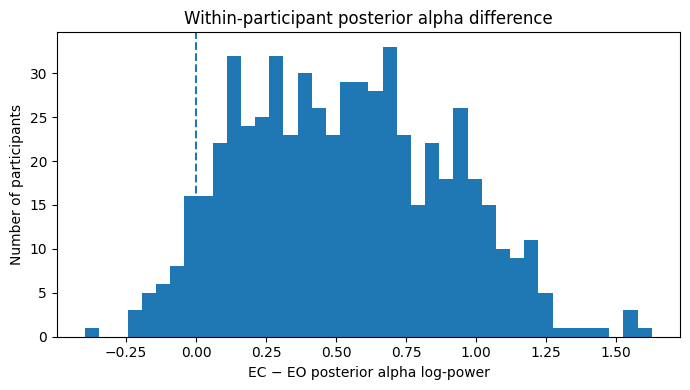

In [4]:
alpha_wide = paired.pivot(
    index="participant_id",
    columns="condition",
    values="posterior_alpha_log",
).dropna()

alpha_wide["EC_minus_EO"] = alpha_wide["EC"] - alpha_wide["EO"]

print("Participants:", len(alpha_wide))
print("Proportion EC > EO:", (alpha_wide["EC_minus_EO"] > 0).mean())

display(alpha_wide["EC_minus_EO"].describe())

plt.figure(figsize=(7, 4))
plt.hist(alpha_wide["EC_minus_EO"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("EC − EO posterior alpha log-power")
plt.ylabel("Number of participants")
plt.title("Within-participant posterior alpha difference")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "paired_alpha_difference_hist.png", dpi=300)
plt.show()


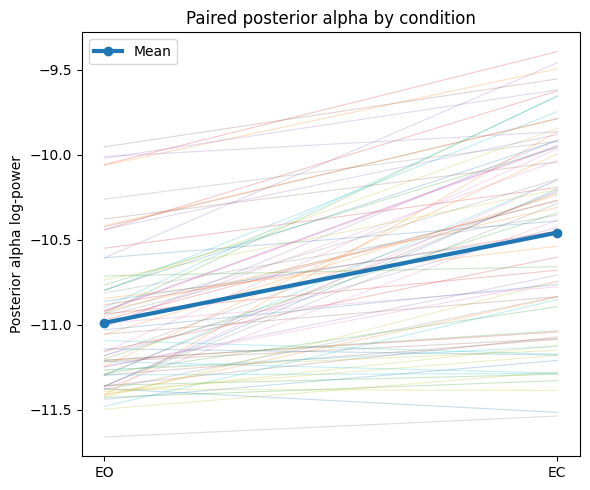

In [5]:
# Paired line plot for a readable subset.
rng = np.random.default_rng(42)
plot_subjects = rng.choice(alpha_wide.index, size=min(80, len(alpha_wide)), replace=False)

plot_df = paired[paired["participant_id"].isin(plot_subjects)].copy()
plot_df["x"] = plot_df["condition"].map({"EO": 0, "EC": 1})

plt.figure(figsize=(6, 5))

for participant_id, group in plot_df.groupby("participant_id"):
    group = group.sort_values("x")
    plt.plot(group["x"], group["posterior_alpha_log"], alpha=0.25, linewidth=0.8)

means = paired.groupby("condition")["posterior_alpha_log"].mean().reindex(["EO", "EC"])
plt.plot([0, 1], means.values, marker="o", linewidth=3, label="Mean")

plt.xticks([0, 1], ["EO", "EC"])
plt.ylabel("Posterior alpha log-power")
plt.title("Paired posterior alpha by condition")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "paired_posterior_alpha_lines_model_sample.png", dpi=300)
plt.show()


## 4. Helper functions for paired analyses

In [6]:
def bootstrap_accuracy_ci(correct, n_boot=5000, seed=42):
    """Bootstrap a 95% CI for accuracy by resampling participants."""
    correct = np.asarray(correct).astype(float)
    rng = np.random.default_rng(seed)

    boot = []
    n = len(correct)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot.append(correct[idx].mean())

    return np.percentile(boot, [2.5, 97.5])


def stable_hash_is_even(text):
    """Stable condition-independent pseudo-random choice based on participant ID."""
    digest = hashlib.md5(str(text).encode("utf-8")).hexdigest()
    return int(digest, 16) % 2 == 0


def make_pair_wide(df, columns):
    """Create a wide table with EC and EO values for selected columns."""
    wide = df.pivot(
        index="participant_id",
        columns="condition",
        values=columns,
    )

    # Flatten MultiIndex columns: feature_EC, feature_EO.
    wide.columns = [f"{feature}_{condition}" for feature, condition in wide.columns]
    wide = wide.reset_index()

    return wide


def simple_paired_rule(df, feature_col, model_name):
    """Evaluate rule: the condition with higher feature value is predicted as EC."""
    wide = make_pair_wide(df, [feature_col]).dropna()

    ec_col = f"{feature_col}_EC"
    eo_col = f"{feature_col}_EO"

    wide["correct"] = wide[ec_col] > wide[eo_col]
    wide["predicted_EC_condition"] = np.where(wide["correct"], "EC", "EO")

    ci_low, ci_high = bootstrap_accuracy_ci(wide["correct"])

    result = {
        "setting": "paired",
        "model_name": model_name,
        "feature_set": feature_col,
        "n_pairs": len(wide),
        "accuracy": wide["correct"].mean(),
        "balanced_accuracy": np.nan,
        "roc_auc": np.nan,
        "ci_lower": ci_low,
        "ci_upper": ci_high,
        "notes": "Simple paired rule: higher feature value is predicted as EC.",
    }

    pred = wide[["participant_id", "correct", "predicted_EC_condition"]].copy()
    pred["setting"] = "paired"
    pred["model_name"] = model_name
    pred["y_true"] = np.nan
    pred["y_pred"] = np.nan
    pred["y_proba"] = np.nan

    return result, pred


def make_order_independent_pair_dataset(df, feature_cols):
    """Create one order-independent paired-difference row per participant.

    For each participant, choose whether A is EC or EO using a stable hash of the
    participant ID. This choice is independent of the feature values.

    X = features_A - features_B
    y = 1 if A is EC, 0 if A is EO
    """
    needed = ["participant_id", "condition"] + feature_cols
    d = df[needed].copy()

    rows = []

    for participant_id, group in d.groupby("participant_id"):
        if set(group["condition"]) != {"EC", "EO"}:
            continue

        ec = group[group["condition"] == "EC"].iloc[0]
        eo = group[group["condition"] == "EO"].iloc[0]

        a_is_ec = stable_hash_is_even(participant_id)

        if a_is_ec:
            A = ec
            B = eo
            y = 1
        else:
            A = eo
            B = ec
            y = 0

        row = {
            "participant_id": participant_id,
            "A_condition": A["condition"],
            "B_condition": B["condition"],
            "y": y,
        }

        for col in feature_cols:
            row[col] = A[col] - B[col]

        rows.append(row)

    pair_df = pd.DataFrame(rows)

    X = pair_df[feature_cols].copy()
    y = pair_df["y"].astype(int).copy()

    return pair_df, X, y


def run_paired_logistic_cv(df, feature_cols, model_name, penalty="l2", C=1.0):
    """Run 5-fold CV paired logistic regression using paired differences."""
    pair_df, X, y = make_order_independent_pair_dataset(df, feature_cols)

    # Drop columns that are entirely missing.
    valid_cols = [col for col in feature_cols if not X[col].isna().all()]
    X = X[valid_cols]

    if len(valid_cols) == 0:
        raise ValueError(f"No valid features for {model_name}.")

    solver = "liblinear" if penalty == "l1" else "lbfgs"

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=5000,
            random_state=42,
        )),
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    pred_rows = []
    coef_rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        test_participants = pair_df.iloc[test_idx]["participant_id"].values

        for participant_id, true, pred, proba in zip(test_participants, y_test, y_pred, y_proba):
            pred_rows.append({
                "participant_id": participant_id,
                "setting": "paired",
                "model_name": model_name,
                "fold": fold,
                "y_true": int(true),
                "y_pred": int(pred),
                "y_proba": float(proba),
                "correct": bool(true == pred),
                "predicted_EC_condition": np.nan,
            })

        logreg = model.named_steps["logreg"]
        coefs = logreg.coef_[0]

        for feature, coef in zip(valid_cols, coefs):
            coef_rows.append({
                "setting": "paired",
                "model_name": model_name,
                "fold": fold,
                "feature": feature,
                "coefficient": coef,
            })

    predictions = pd.DataFrame(pred_rows)
    coefficients = pd.DataFrame(coef_rows)

    acc = accuracy_score(predictions["y_true"], predictions["y_pred"])
    bal_acc = balanced_accuracy_score(predictions["y_true"], predictions["y_pred"])

    try:
        auc = roc_auc_score(predictions["y_true"], predictions["y_proba"])
    except ValueError:
        auc = np.nan

    ci_low, ci_high = bootstrap_accuracy_ci(predictions["correct"])

    result = {
        "setting": "paired",
        "model_name": model_name,
        "feature_set": ", ".join(valid_cols),
        "n_pairs": len(predictions),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "roc_auc": auc,
        "ci_lower": ci_low,
        "ci_upper": ci_high,
        "notes": (
            "Paired logistic regression using order-independent feature differences. "
            f"Penalty={penalty}, C={C}."
        ),
    }

    return result, predictions, coefficients


## 5. Simple paired alpha rules

These directly implement the simple paired rule:

> For each participant, the recording with higher alpha power is classified as EC.

This requires no training and no cross-validation.


In [7]:
simple_rule_features = {
    "simple_rule_oz_alpha": "oz_alpha_log",
    "simple_rule_occipital_alpha": "occipital_alpha_log",
    "simple_rule_posterior_alpha": "posterior_alpha_log",
}

all_results = []
all_predictions = []
all_coefficients = []

for model_name, feature_col in simple_rule_features.items():
    result, pred = simple_paired_rule(paired, feature_col, model_name)
    all_results.append(result)
    all_predictions.append(pred)

simple_results = pd.DataFrame(all_results)

display(simple_results[[
    "model_name",
    "n_pairs",
    "accuracy",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_pairs,accuracy,ci_lower,ci_upper
0,simple_rule_oz_alpha,591,0.934010,0.913706,0.952623
1,simple_rule_occipital_alpha,591,0.944162,0.923858,0.962775
2,simple_rule_posterior_alpha,591,0.937394,0.918782,0.956007


## 6. Define complex feature sets

The main complex comparison is not only FOOOF. It includes richer posterior-channel and multiband features.


In [8]:
posterior_channel_alpha_features = [
    col for col in paired.columns
    if col.startswith("ch_") and col.endswith("_alpha_log")
]

welch_multiband_features = [
    "posterior_delta_log",
    "posterior_theta_log",
    "posterior_alpha_log",
    "posterior_beta_log",
    "posterior_high_beta_log",
    "posterior_alpha_rel",
]

welch_multiband_features = [
    col for col in welch_multiband_features
    if col in paired.columns
]

fooof_features = [
    "fooof_alpha_cf",
    "fooof_alpha_peak_power",
    "fooof_alpha_bandwidth",
    "fooof_aperiodic_exponent",
]

fooof_features = [
    col for col in fooof_features
    if col in paired.columns
]

combined_features = list(dict.fromkeys(
    posterior_channel_alpha_features
    + welch_multiband_features
    + fooof_features
))

feature_sets = {
    "paired_lr_posterior_alpha_L2": ["posterior_alpha_log"],
    "paired_lr_posterior_channels_L2": posterior_channel_alpha_features,
    "paired_lr_welch_multiband_L2": welch_multiband_features,
}

if len(fooof_features) > 0:
    feature_sets["paired_lr_fooof_L2"] = fooof_features
    feature_sets["paired_lr_combined_L2"] = combined_features

print("N posterior channel alpha features:", len(posterior_channel_alpha_features))
print("Welch multiband features:", welch_multiband_features)
print("FOOOF features:", fooof_features)
print("N combined features:", len(combined_features))


N posterior channel alpha features: 19
Welch multiband features: ['posterior_delta_log', 'posterior_theta_log', 'posterior_alpha_log', 'posterior_beta_log', 'posterior_high_beta_log', 'posterior_alpha_rel']
FOOOF features: ['fooof_alpha_cf', 'fooof_alpha_peak_power', 'fooof_alpha_bandwidth', 'fooof_aperiodic_exponent']
N combined features: 29


## 7. Paired logistic-regression models

Each participant contributes one paired-difference row.

The order of the difference is chosen using a stable hash of the participant ID, not using the condition label. This avoids constructing every row as EC − EO and then trying to classify a label that is already encoded in the subtraction direction.


In [9]:
for model_name, feature_cols in feature_sets.items():
    result, pred, coef = run_paired_logistic_cv(
        paired,
        feature_cols,
        model_name=model_name,
        penalty="l2",
        C=1.0,
    )

    all_results.append(result)
    all_predictions.append(pred)
    all_coefficients.append(coef)

paired_results = pd.DataFrame(all_results)
paired_predictions = pd.concat(all_predictions, ignore_index=True)

if len(all_coefficients) > 0:
    paired_coefficients = pd.concat(all_coefficients, ignore_index=True)
else:
    paired_coefficients = pd.DataFrame()

display(paired_results[[
    "model_name",
    "n_pairs",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_pairs,accuracy,balanced_accuracy,roc_auc,ci_lower,ci_upper
0,simple_rule_oz_alpha,591,0.934010,NaN,NaN,0.913706,0.952623
1,simple_rule_occipital_alpha,591,0.944162,NaN,NaN,0.923858,0.962775
2,simple_rule_posterior_alpha,591,0.937394,NaN,NaN,0.918782,0.956007
3,paired_lr_posterior_alpha_L2,591,0.942470,0.942459,0.988284,0.923858,0.961083
4,paired_lr_posterior_channels_L2,591,0.942470,0.942464,0.989682,0.923858,0.961083
5,paired_lr_welch_multiband_L2,591,0.974619,0.974611,0.996370,0.961083,0.986464
6,paired_lr_fooof_L2,591,0.945854,0.945872,0.989017,0.927242,0.962775
7,paired_lr_combined_L2,591,0.967851,0.967860,0.996622,0.952623,0.981387


## 8. L1-regularized models

L1 regularization can be interpreted as a simple feature-selection check. It is useful for asking whether the multifeature model mainly keeps posterior alpha-related features.


In [10]:
RUN_L1_MODELS = True

if RUN_L1_MODELS:
    l1_feature_sets = {
        "paired_lr_posterior_channels_L1": posterior_channel_alpha_features,
        "paired_lr_welch_multiband_L1": welch_multiband_features,
    }

    if len(fooof_features) > 0:
        l1_feature_sets["paired_lr_combined_L1"] = combined_features

    for model_name, feature_cols in l1_feature_sets.items():
        result, pred, coef = run_paired_logistic_cv(
            paired,
            feature_cols,
            model_name=model_name,
            penalty="l1",
            C=1.0,
        )

        all_results.append(result)
        all_predictions.append(pred)
        all_coefficients.append(coef)

    paired_results = pd.DataFrame(all_results)
    paired_predictions = pd.concat(all_predictions, ignore_index=True)
    paired_coefficients = pd.concat(all_coefficients, ignore_index=True)

display(paired_results[[
    "model_name",
    "n_pairs",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_pairs,accuracy,balanced_accuracy,roc_auc,ci_lower,ci_upper
0,simple_rule_oz_alpha,591,0.934010,NaN,NaN,0.913706,0.952623
1,simple_rule_occipital_alpha,591,0.944162,NaN,NaN,0.923858,0.962775
2,simple_rule_posterior_alpha,591,0.937394,NaN,NaN,0.918782,0.956007
3,paired_lr_posterior_alpha_L2,591,0.942470,0.942459,0.988284,0.923858,0.961083
4,paired_lr_posterior_channels_L2,591,0.942470,0.942464,0.989682,0.923858,0.961083
5,paired_lr_welch_multiband_L2,591,0.974619,0.974611,0.996370,0.961083,0.986464
6,paired_lr_fooof_L2,591,0.945854,0.945872,0.989017,0.927242,0.962775
7,paired_lr_combined_L2,591,0.967851,0.967860,0.996622,0.952623,0.981387
8,paired_lr_posterior_channels_L1,591,0.939086,0.939080,0.989670,0.920474,0.957699
9,paired_lr_welch_multiband_L1,591,0.974619,0.974628,0.996839,0.961083,0.986464


## 9. Save paired results

In [11]:
paired_results.to_csv(PAIRED_RESULTS_FILE, index=False)
paired_predictions.to_csv(PAIRED_PREDICTIONS_FILE, index=False)

if len(paired_coefficients) > 0:
    paired_coefficients.to_csv(PAIRED_COEFFICIENTS_FILE, index=False)

print("Saved:", PAIRED_RESULTS_FILE)
print("Saved:", PAIRED_PREDICTIONS_FILE)
print("Saved:", PAIRED_COEFFICIENTS_FILE if len(paired_coefficients) > 0 else "No coefficients saved")


Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\paired_results.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\paired_predictions.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\paired_coefficients.csv


## 10. Figure: paired model performance

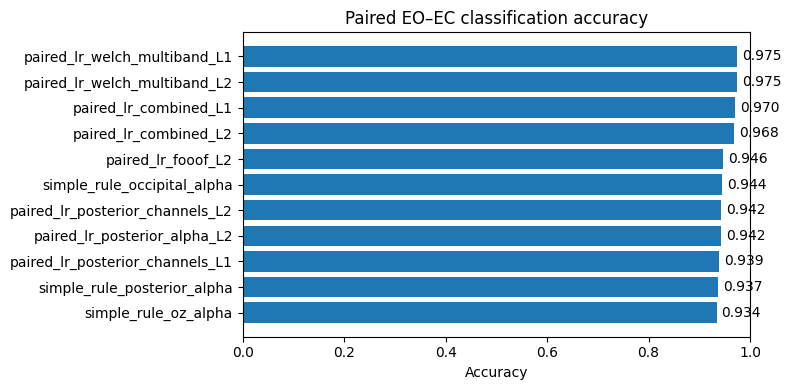

In [12]:
plot_results = paired_results.copy()
plot_results = plot_results.sort_values("accuracy", ascending=True)

plt.figure(figsize=(8, max(4, 0.35 * len(plot_results))))
plt.barh(plot_results["model_name"], plot_results["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Paired EO–EC classification accuracy")

for i, (_, row) in enumerate(plot_results.iterrows()):
    plt.text(
        row["accuracy"] + 0.01,
        i,
        f"{row['accuracy']:.3f}",
        va="center",
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "paired_model_accuracy.png", dpi=300)
plt.show()


## 11. Figure: coefficient stability for selected model

This plot summarizes coefficients across CV folds for the posterior-channel alpha model. Large positive or negative coefficients indicate features that influence the paired classification decision.


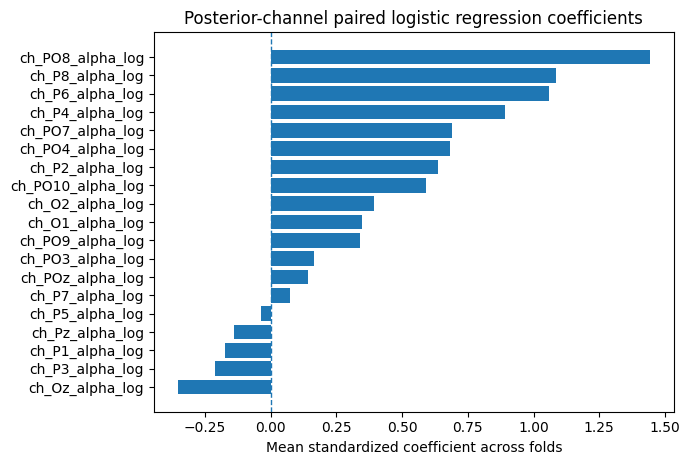

,feature,mean_coefficient,sd_coefficient
2,ch_Oz_alpha_log,-0.353446,0.145670
5,ch_P3_alpha_log,-0.212413,0.107813
3,ch_P1_alpha_log,-0.172332,0.142698
18,ch_Pz_alpha_log,-0.138877,0.085595
7,ch_P5_alpha_log,-0.038185,0.057522
9,ch_P7_alpha_log,0.073829,0.115492
17,ch_POz_alpha_log,0.142888,0.088098
12,ch_PO3_alpha_log,0.167012,0.187960
16,ch_PO9_alpha_log,0.341833,0.080525
0,ch_O1_alpha_log,0.347584,0.119892


In [13]:
selected_model = "paired_lr_posterior_channels_L2"

if len(paired_coefficients) > 0 and selected_model in paired_coefficients["model_name"].unique():
    coef_summary = (
        paired_coefficients
        .query("model_name == @selected_model")
        .groupby("feature")
        .agg(
            mean_coefficient=("coefficient", "mean"),
            sd_coefficient=("coefficient", "std"),
        )
        .reset_index()
        .sort_values("mean_coefficient")
    )

    plt.figure(figsize=(7, max(4, 0.25 * len(coef_summary))))
    plt.barh(coef_summary["feature"], coef_summary["mean_coefficient"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Mean standardized coefficient across folds")
    plt.title("Posterior-channel paired logistic regression coefficients")
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "paired_posterior_channel_coefficients.png", dpi=300)
    plt.show()

    display(coef_summary)
else:
    print(f"No coefficients found for {selected_model}.")
